# Proyecto Parte 2: Clasificación de Década con Deep Learning y Aumentación de Datos

**Objetivo:** Dado un párrafo en español, predecir la **década** en que fue escrito.
**Métrica:** *Accuracy*.


## 1. Verificación / Instalación de dependencias

La celda siguiente **detecta el entorno** (Kaggle, Colab o local) y solo intenta instalar paquetes faltantes si hay internet disponible.

- **PyTorch + Transformers:** Núcleo del modelo de Deep Learning.
- **scikit-learn:** Métricas y split estratificado.
- **matplotlib / seaborn:** Visualizaciones.
- **sentencepiece / accelerate:** Dependencias internas de tokenizadores y entrenamiento mixto.

In [ ]:
import importlib, subprocess, sys, socket, os

REQUIRED = {
    "torch":         "torch",
    "transformers":  "transformers",
    "sklearn":       "scikit-learn",
    "pandas":        "pandas",
    "numpy":         "numpy",
    "matplotlib":    "matplotlib",
    "seaborn":       "seaborn",
    "sentencepiece": "sentencepiece",
}


def _detect_env():
    if "KAGGLE_KERNEL_RUN_TYPE" in os.environ or os.path.exists("/kaggle"):
        return "kaggle"
    try:
        import google.colab 
        return "colab"
    except Exception:
        return "local"


def _has_internet(host="pypi.org", port=443, timeout=3):
    try:
        socket.setdefaulttimeout(timeout)
        socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect((host, port))
        return True
    except Exception:
        return False


ENV = _detect_env()
print(f"Entorno detectado: {ENV}")

missing = []
for mod, pkg in REQUIRED.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(pkg)

if not missing:
    print("Todas las dependencias requeridas ya están instaladas. No se necesita pip install.")
else:
    print(f"Faltan paquetes: {missing}")
    if _has_internet():
        print("Internet disponible; instalando paquetes faltantes...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
        print("Instalación completa. Reinicie el kernel si alguna importación falla.")
    else:
        print(
            "\n[!] Internet no disponible (típico en Kaggle con 'Internet: Off').\n"
            "    Active el internet en Settings → Internet: On (requiere verificar\n"
            "    teléfono una sola vez) y reejecute esta celda; o bien instale los\n"
            "    paquetes faltantes en un entorno con internet."
        )

import torch, transformers
print(f"\ntorch        : {torch.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")


Entorno detectado: kaggle
Todas las dependencias requeridas ya están instaladas. No se necesita pip install.

torch        : 2.10.0+cu128
transformers : 5.0.0
CUDA disponible: True
GPU          : Tesla T4



Se fijan versiones para garantizar **reproducibilidad**. La versión `transformers == 4.44.x` es estable con `torch >= 2.1` y soporta los tokenizadores Spanish/multilingüe utilizados más adelante.

## 2. Configuración global


In [2]:
import os
import re
import gc
import json
import time
import random
import warnings
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM, get_linear_schedule_with_warmup

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Dispositivo: cuda
GPU: Tesla T4



- `SEED=42` se usa en `random`, `numpy`, `torch` y `torch.cuda` para que el split, la aumentación y el entrenamiento sean reproducibles.
- Si hay GPU se entrena allí.
- Si no hay GPU el notebook igual funciona.


## 3. Carga de los datos

Los archivos están en la carpeta `Data/`:

- `train.csv`: `text` (string) y `decade` (entero entre 150 y 188).
- `eval.csv`: `id` (entero) y `text` (string). No tiene etiquetas.


In [3]:
def _find_data_dir():
    """Busca train.csv + eval.csv en ubicaciones típicas y, si no los encuentra,
    hace una búsqueda recursiva en /kaggle/input y en el cwd.

    Devuelve la primera carpeta que contenga AMBOS archivos.
    """
    explicit = [
        "Data", "data", "./Data", "./data",
        "/kaggle/input/datasets/juanrodrigueztorres/dataset",
        "/kaggle/input/dataset", "/kaggle/input/data",
        "/kaggle/working/Data", "/kaggle/working/data",
    ]
    for c in explicit:
        if os.path.isfile(os.path.join(c, "train.csv")) and os.path.isfile(os.path.join(c, "eval.csv")):
            return c

    search_roots = []
    if os.path.isdir("/kaggle/input"):
        search_roots.append("/kaggle/input")
    search_roots.append(".")

    print("Buscando train.csv + eval.csv recursivamente en:", search_roots)
    found_any = []
    for root_dir in search_roots:
        for root, _dirs, files in os.walk(root_dir, topdown=True):
            if "train.csv" in files and "eval.csv" in files:
                print(f"  -> encontrado en: {root}")
                return root
            for f in files:
                if f in ("train.csv", "eval.csv"):
                    found_any.append(os.path.join(root, f))

    if found_any:
        print("\nSe encontraron archivos sueltos (no ambos en la misma carpeta):")
        for p in found_any:
            print("  ", p)

    if os.path.isdir("/kaggle/input"):
        print("\nÁrbol de /kaggle/input/ (para diagnóstico):")
        for root, dirs, files in os.walk("/kaggle/input"):
            rel = root.replace("/kaggle/input", "/kaggle/input") or "."
            print(f"  {rel}  ->  {files[:8]}{'...' if len(files) > 8 else ''}")

    raise FileNotFoundError(
        "No encuentro train.csv + eval.csv en la misma carpeta. "
        "Si los CSV están sueltos en distintos paths, fija DATA_DIR manualmente, "
        "por ejemplo: DATA_DIR = '/kaggle/input/dataset'"
    )


DATA_DIR = _find_data_dir()
print(f"\n>>> DATA_DIR detectado: {DATA_DIR}")

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
eval_df  = pd.read_csv(os.path.join(DATA_DIR, "eval.csv"))

print("Train shape:", train_df.shape)
print("Eval  shape:", eval_df.shape)
print()
print("Primeros ejemplos de train:")
try:
    display(train_df.head(3))
except NameError:
    print(train_df.head(3))
print()
print("Primeros ejemplos de eval:")
try:
    display(eval_df.head(3))
except NameError:
    print(eval_df.head(3))


Buscando train.csv + eval.csv recursivamente en: ['/kaggle/input', '.']
  -> encontrado en: /kaggle/input/datasets/joinsite/dataset

>>> DATA_DIR detectado: /kaggle/input/datasets/joinsite/dataset
Train shape: (31403, 2)
Eval  shape: (3490, 2)

Primeros ejemplos de train:


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157



Primeros ejemplos de eval:


,id,text
0,0,P. Si en efta convocación trato folament...
1,1,«Muy santo Padre : Ayer escribiá don Juan Man-...
2,2,"Recibo, otorgado por Diego Gracián a favor de ..."



- **31,403** ejemplos de entrenamiento y **3,490** de evaluación.
- Las clases (décadas) están bien **balanceadas**, así que no necesitamos rebalanceo.
- Los textos son fragmentos en **español histórico** obtenidos por OCR de fuentes antiguas.

## 4. Análisis exploratorio (EDA)

Verificamos:
1. Distribución de clases.
2. Distribución de longitudes (en caracteres y palabras) para decidir `MAX_LEN`.


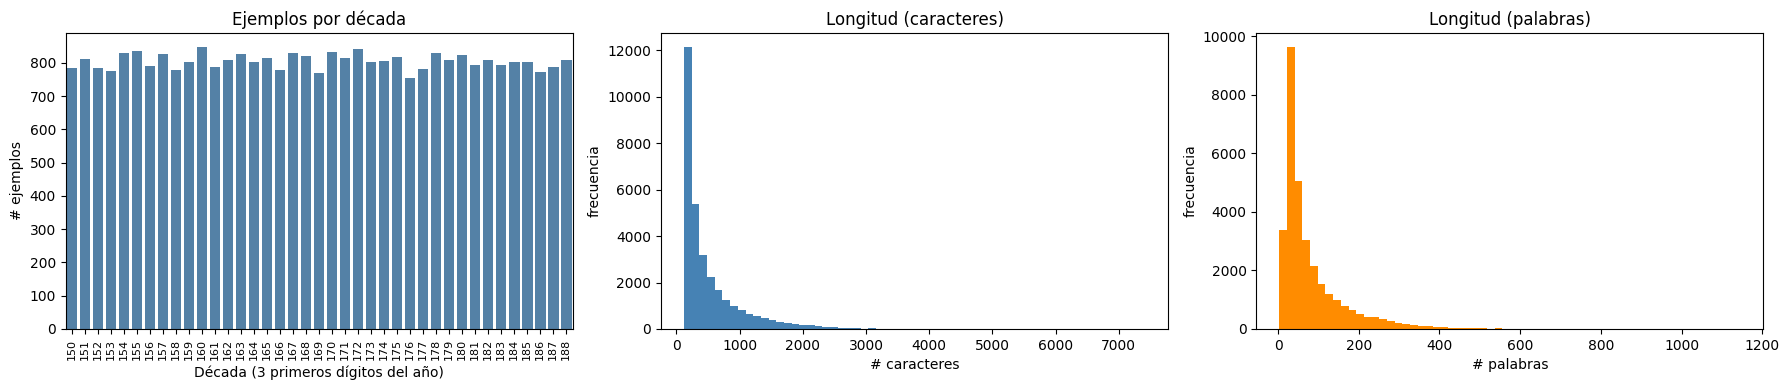

Estadísticas de longitudes en palabras:
count    31403.0
mean        82.3
std         82.4
min          3.0
25%         30.0
50%         50.0
75%        102.0
max       1146.0
Name: text, dtype: float64


In [4]:
decade_counts = train_df["decade"].value_counts().sort_index()
char_lens = train_df["text"].str.len()
word_lens = train_df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(x=decade_counts.index, y=decade_counts.values, ax=axes[0], color="steelblue")
axes[0].set_title("Ejemplos por década")
axes[0].set_xlabel("Década (3 primeros dígitos del año)")
axes[0].set_ylabel("# ejemplos")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)

axes[1].hist(char_lens, bins=60, color="steelblue")
axes[1].set_title("Longitud (caracteres)")
axes[1].set_xlabel("# caracteres"); axes[1].set_ylabel("frecuencia")

axes[2].hist(word_lens, bins=60, color="darkorange")
axes[2].set_title("Longitud (palabras)")
axes[2].set_xlabel("# palabras"); axes[2].set_ylabel("frecuencia")

plt.tight_layout()
plt.show()

print("Estadísticas de longitudes en palabras:")
print(word_lens.describe().round(1))




- **39 clases balanceadas:** Problema multiclase plano (un sólo `softmax` con 39 salidas). Usaremos *label smoothing* leve para no sobre-confiarnos en clases vecinas.
- **Longitudes:** La mediana ronda 50 palabras y el percentil 95 está alrededor de aproximadamente 180 palabras. Con tokenización subword esto equivale aproximadamente a 80–300 tokens. Fijamos `MAX_LEN = 256` como compromiso entre cobertura y velocidad. Para textos más largos se hará *truncation* en entrenamiento y *chunk averaging* opcional en inferencia.


## 5. Preprocesamiento de texto

Los textos provienen de OCR sobre documentos históricos. Las decisiones de limpieza son conservadoras: queremos eliminar ruido evidente pero **conservar** marcas estilísticas que pueden ser pistas temporales (uso de "f" larga por "s", grafías arcaicas, etc.).


In [5]:
REPLACEMENT_CHARS = "\ufffd\u00ad"   # carácter de reemplazo y soft hyphen

def clean_text(text: str) -> str:
    """Limpieza ligera y conservadora.

    - Elimina caracteres de reemplazo y soft hyphens.
    - Convierte cualquier secuencia de espacios/saltos en un solo espacio.
    - Une palabras partidas por guión de fin de línea ("colu-\nmna" -> "columna").
    - Elimina controles ASCII.
    """
    if not isinstance(text, str):
        return ""
    text = re.sub(r"-\s*\n\s*", "", text)          # guión de fin de línea
    text = re.sub(f"[{REPLACEMENT_CHARS}]", "", text)
    text = re.sub(r"[\x00-\x1f\x7f-\x9f]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


train_df["text"] = train_df["text"].astype(str).map(clean_text)
eval_df["text"]  = eval_df["text"].astype(str).map(clean_text)

# Eliminamos eventuales filas vacías tras la limpieza
train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)

print("Tras limpieza:")
print("  Train:", train_df.shape)
print("  Eval :", eval_df.shape)
print()
print("Ejemplo limpio:")
print(train_df.iloc[0]["text"][:300])


Tras limpieza:
  Train: (31403, 2)
  Eval : (3490, 2)

Ejemplo limpio:
Honorarias ¡jubiladas. 57 dit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 pag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len nes parece que aísilte, O ayuda Calsiodoro lib,6.epuft.s 2.Donde * llama Ocloso CINGV- y 19


### Documentación

- **Por qué tan poca limpieza:** ortografías arcaicas como "f" larga, dobles "ss", terminaciones en "-ades" en lugar de "-ades" modernas, abreviaturas latinas (`ítem`, `dicho`), etc. son señal, no ruido. Eliminarlas borraría la información que el modelo necesita para distinguir entre décadas cercanas.
- **Qué sí se elimina:** caracteres de reemplazo `U+FFFD`, soft hyphens, controles ASCII y los guiones de fin de línea (artefacto típico de OCR sobre libros con texto justificado).
- Los caracteres "exóticos" residuales (`ǭ`, `Ǹ`, …) **se conservan**: el tokenizador subword los romperá en bytes UTF-8 y el modelo aprenderá a tratarlos.


## 6. Codificación de etiquetas

El modelo necesita índices `0..N-1` en lugar de las décadas crudas `150..188`. Construimos `label2id` (para entrenar) e `id2label` (para volver al espacio de décadas y poder escribir el `submission.csv`).


In [6]:
labels_sorted = sorted(train_df["decade"].unique().tolist())
label2id = {d: i for i, d in enumerate(labels_sorted)}
id2label = {i: d for d, i in label2id.items()}
N_CLASSES = len(labels_sorted)

train_df["label"] = train_df["decade"].map(label2id)

print(f"Número de clases: {N_CLASSES}")
print(f"Década mínima: {labels_sorted[0]}  (año {labels_sorted[0]*10}s)")
print(f"Década máxima: {labels_sorted[-1]} (año {labels_sorted[-1]*10}s)")


Número de clases: 39
Década mínima: 150  (año 1500s)
Década máxima: 188 (año 1880s)



- 39 clases ordenadas cronológicamente. Al ser **ordinales** la diferencia `|pred - true|` tiene sentido (un error de 1 década es menos grave que uno de 10). Nuestro `id2label` preserva ese orden por construcción.


## 7. Separación interna train/val

Usamos un *split estratificado por clase* (10% para validación) para que cada década esté representada proporcionalmente en validación, y así el accuracy interno sea un estimador fiable del público.


In [7]:
train_split, val_split = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    stratify=train_df["label"],
)
train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)
print(f"Train interno: {len(train_split):>6}   Val interno: {len(val_split):>6}")


Train interno:  28262   Val interno:   3141



- 10% de validación ≈ 3,140 ejemplos, suficiente para que el estimador de accuracy tenga una desviación estándar < 1 punto.
- **`stratify=train_df["label"]`** garantiza que las 39 décadas estén proporcionalmente en val. Sin esta cláusula, alguna década podría quedar sub-representada.


## 8. Aumentación de datos (sintética, en tiempo de entrenamiento)

> **Requisito del PDF:** *"Está permitido el uso de datos sintéticos para entrenar los modelos, pero debe describir en detalle cómo realizó la construcción."*

Implementamos **cuatro estrategias** que se aplican estocásticamente cada vez que se lee un ejemplo durante el entrenamiento. Esto multiplica de facto el tamaño del dataset sin requerir almacenamiento extra. Todas operan sobre el texto **ya limpio** descrito en la sección 5.

### 8.1 `random_window` — muestreo de ventanas
Para textos largos, recorta una ventana contigua de longitud aleatoria. **Motivación:** el modelo debe aprender que el estilo temporal está presente en *cualquier* fragmento del párrafo, no solo al inicio.

### 8.2 `word_dropout` — eliminación aleatoria de palabras
Elimina cada palabra con probabilidad pequeña. Equivalente textual al *dropout* en redes neuronales. Forzamos al modelo a no depender de palabras concretas individuales.

### 8.3 `word_swap` — intercambio adyacente de palabras
Intercambia el orden de dos palabras (idealmente cercanas). Pequeña perturbación sintáctica que actúa como regularizador.

### 8.4 `ocr_noise` — ruido OCR simulado
Sustituye caracteres con probabilidad muy baja siguiendo confusiones típicas del OCR sobre textos antiguos (`s↔f`, vocales acentuadas ↔ sin acento, `ñ↔n`). **Motivación:** los textos de test pueden tener artefactos OCR ligeramente distintos a los de train, así que entrenamos al modelo a ser robusto a ellos.


> **Importante:** la aumentación se aplica únicamente al **split interno de entrenamiento**, nunca al split de validación ni al `eval.csv`.


In [8]:
# Sustituciones de OCR plausibles en textos hispánicos antiguos.
# La "ſ" (s larga) suele transcribirse como "f"; el carácter "ñ" a veces
# pierde la tilde; algunas vocales pierden el acento al ser OCR'd.
SPANISH_OCR_SUBS = {
    "s": "f", "f": "s",
    "í": "i", "á": "a", "é": "e", "ó": "o", "ú": "u",
    "ñ": "n",
}


def aug_random_window(text: str, min_words: int = 50, max_words: int = 200) -> str:
    """Recorta una ventana contigua aleatoria del texto."""
    words = text.split()
    if len(words) <= min_words:
        return text
    n = random.randint(min_words, min(max_words, len(words)))
    start = random.randint(0, len(words) - n)
    return " ".join(words[start:start + n])


def aug_word_dropout(text: str, p: float = 0.08) -> str:
    """Elimina cada palabra con probabilidad p."""
    words = text.split()
    kept = [w for w in words if random.random() > p]
    return " ".join(kept) if kept else text


def aug_word_swap(text: str, n_swaps: int = 1) -> str:
    """Intercambia n_swaps pares de palabras adyacentes."""
    words = text.split()
    if len(words) < 2:
        return text
    for _ in range(n_swaps):
        i = random.randint(0, len(words) - 2)
        words[i], words[i + 1] = words[i + 1], words[i]
    return " ".join(words)


def aug_ocr_noise(text: str, p: float = 0.01) -> str:
    """Sustituye caracteres con probabilidad p siguiendo el diccionario de OCR."""
    out = []
    for ch in text:
        low = ch.lower()
        if random.random() < p and low in SPANISH_OCR_SUBS:
            sub = SPANISH_OCR_SUBS[low]
            out.append(sub.upper() if ch.isupper() else sub)
        else:
            out.append(ch)
    return "".join(out)


def augment_text(text: str) -> str:
    """Pipeline estocástico aplicado en tiempo de entrenamiento.

    Probabilidades suavizadas respecto a la versión inicial para no degradar
    demasiado los textos (el modelo necesita ver suficientes ejemplos "limpios"
    para distinguir décadas vecinas).
    """
    if random.random() < 0.5:
        text = aug_random_window(text, min_words=50, max_words=200)
    if random.random() < 0.20:
        text = aug_word_dropout(text, p=0.05)
    if random.random() < 0.15:
        text = aug_word_swap(text, n_swaps=1)
    if random.random() < 0.15:
        text = aug_ocr_noise(text, p=0.005)
    return text


# ---- Comprobación rápida ----
sample = train_split.iloc[0]["text"]
print("ORIGINAL:\n", sample[:300], "\n")
random.seed(0)
for i in range(3):
    print(f"AUMENTADO {i+1}:\n", augment_text(sample)[:300], "\n")


ORIGINAL:
 Aquel consuelo con que S. Fruéluoso asegiuró á los Fieles de Tarragona , que en adelante no les faltarla Pastor , es preciso le supongamos verídico , por afirmar las Aélas que lo dijo movido por la gracia del- Espirita Santo. Pero como una de las 

AUMENTADO 1:
 Aquel consuelo con que S. Fruéluoso asegiuró á los Fieles de Tarragona , que en adelante no les faltarla Pastor , es preciso le supongamos verídico , por afirmar las Aélas que lo dijo movido por la gracia del- Espirita Santo. Pero como una de las 

AUMENTADO 2:
 Aquel consuelo con que S. Fruéluoso asegiuró á los Fieles de Tarragona , que en adelante no les faltarla Pastor , es preciso le supongamos verídico , por afirmar las Aélas que lo dijo movido por la gracia del- Espirita Santo. Pero como una de las 

AUMENTADO 3:
 Aquel consuelo con que S. Fruéluoso asegiuró á los Fieles de Tarragona , que en adelante no les faltarla Pastor , es preciso le supongamos verídico , por afirmar las Aélas que lo dijo movido por la gr


- **Por qué *no* usamos back-translation:** los traductores actuales tienden a "normalizar" el español hacia el moderno, lo que **destruye** la pista temporal que es justamente el objetivo de la clasificación.
- **Por qué *no* usamos *synonym replacement* clásico:** los diccionarios de sinónimos de spaCy/WordNet están construidos sobre español moderno; reemplazar "vuestra merced" por "usted" elimina información temporal.

### 8.5 Sobre datos externos (no incluidos en este notebook por defecto)

Documentamos aquí fuentes potencialmente útiles para iteraciones futuras:

| Fuente | Enlace | Licencia | Décadas cubiertas |
|---|---|---|---|
| Proyecto Gutenberg (español) | https://www.gutenberg.org/browse/languages/es | Dominio público en EEUU | 16xx–19xx |
| Biblioteca Virtual Miguel de Cervantes | https://www.cervantesvirtual.com | "Reconocimiento - Compartir Igual" CC BY-SA en gran parte del fondo | 15xx–20xx |
| Wikisource español | https://es.wikisource.org | CC BY-SA 3.0 | 14xx–20xx |
| Corpus del Español (Mark Davies) | https://www.corpusdelespanol.org | Acceso académico (no redistribuible) — **NO USAR** | 12xx–19xx |



In [ ]:
# ============================== HIPERPARÁMETROS ==============================
# Intento principal: RoBERTa-BNE, entrenado sobre corpus de la Biblioteca Nacional de España.

MODEL_CANDIDATES = [
    "BSC-LT/roberta-base-bne",
    "PlanTL-GOB-ES/roberta-base-bne",
    "dccuchile/bert-base-spanish-wwm-cased",
]
MODEL_NAME  = MODEL_CANDIDATES[0]
MAX_LEN     = 384
BATCH_SIZE  = 8            
GRAD_ACCUM_STEPS = 1         
EPOCHS_MAX  = 12             
LR          = 1.5e-5         
WARMUP_PCT  = 0.10
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.05     
GRAD_CLIP   = 1.0
LR_BACKBONE_MULT = 1.0       

FREEZE_BOTTOM_LAYERS = 6     
UNFREEZE_AT_EPOCH    = 4     
UNFREEZE_LR_SCALE     = 1.0  
ç
EARLY_STOP_PATIENCE = 4     

CNN_NUM_FILTERS = 96
CNN_KERNEL_SIZES = (2, 3, 4, 5)
LSTM_HIDDEN = 128
HEAD_DROPOUT = 0.35          

TTA_N_CHUNKS = 5             
TTA_MIN_WORDS = 80          
TTA_WORD_CHUNK_SIZE = 180    
TOP_K_CHECKPOINTS = 5      
RUN_CHECKPOINT_ENSEMBLE_SEARCH = False 
ALPHA_GRID = np.linspace(0.0, 0.35, 36)
TEMPERATURE_GRID = np.array([0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.35], dtype=np.float32)
ENSEMBLE_GAMMAS = (0.0, 0.5, 1.0, 1.5, 2.0, 3.0) 
-
USE_FULL_TRAIN_REFIT = True
REFIT_USE_HOLDOUT_CALIBRATION = True   
SAVE_REFIT_CALIBRATED_ALT = True     
USE_REFIT_SWA = True                   
REFIT_SWA_START_FRAC = 0.60
REFIT_SWA_FINAL_WEIGHT = 0.50       


USE_DAPT = True            
DAPT_EPOCHS = 1
DAPT_MAX_LEN = 256           
DAPT_BATCH_SIZE = 16
DAPT_GRAD_ACCUM_STEPS = 2
DAPT_LR = 5e-5
DAPT_MLM_PROB = 0.15
DAPT_OUTPUT_DIR = "dapt_encoder"

USE_EMBEDDING_LOGREG = False 
EMBED_BATCH_SIZE = 32
LOGREG_C = 2.0

USE_TFIDF_LOGREG = True
USE_TFIDF_IN_FINAL = True
TFIDF_LOGREG_C = 4.0
TFIDF_MAX_ITER = 900
USE_TFIDF_RIDGE = True
TFIDF_RIDGE_ALPHA = 2.0
TFIDF_MIX_WEIGHTS = (0.40, 0.50, 0.60, 0.67, 0.75, 0.85)  


def load_first_available_model_name(candidates):
    last_error = None
    for name in candidates:
        try:
            tok = AutoTokenizer.from_pretrained(name)
            tmp_model = AutoModel.from_pretrained(name)
            del tmp_model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            print(f"Modelo/tokenizer seleccionados: {name}")
            return name, tok
        except Exception as e:
            last_error = e
            print(f"[fallback] No se pudo cargar {name}: {type(e).__name__}: {e}")
    raise RuntimeError(f"Ningún modelo candidato pudo cargarse. Último error: {last_error}")

MODEL_NAME, tokenizer = load_first_available_model_name(MODEL_CANDIDATES)


if "dccuchile/bert-base-spanish-wwm-cased" in MODEL_NAME:
    MAX_LEN = 512
    BATCH_SIZE = 8
    GRAD_ACCUM_STEPS = 2     
    LR = 2e-5
    FREEZE_BOTTOM_LAYERS = 8
    UNFREEZE_AT_EPOCH = 3
    HEAD_DROPOUT = 0.40
    print("Fallback BETO detectado: usando MAX_LEN=512 + grad accumulation.")

print("Tokenizer cargado:", MODEL_NAME)
print("Vocab size:", tokenizer.vocab_size)
print(f"Config efectiva: MAX_LEN={MAX_LEN}, BATCH_SIZE={BATCH_SIZE}, GRAD_ACCUM_STEPS={GRAD_ACCUM_STEPS}, LR={LR}, FREEZE={FREEZE_BOTTOM_LAYERS}, UNFREEZE={UNFREEZE_AT_EPOCH}, DROPOUT={HEAD_DROPOUT}")


class MLMDataset(Dataset):

    def __init__(self, texts, tokenizer, max_len):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, max_length=self.max_len,
            padding="max_length", return_tensors="pt"
        )
        return {k: v.squeeze(0) for k, v in enc.items()}


def mask_tokens(batch, tokenizer, mlm_probability=DAPT_MLM_PROB):
    inputs = batch["input_ids"].clone()
    labels = inputs.clone()
    probability_matrix = torch.full(labels.shape, mlm_probability, device=labels.device)
    special_mask = torch.zeros_like(labels, dtype=torch.bool)
    for special_id in [tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id, tokenizer.mask_token_id]:
        if special_id is not None:
            special_mask |= labels.eq(special_id)
    probability_matrix.masked_fill_(special_mask, 0.0)
    masked_indices = torch.bernoulli(probability_matrix).bool()
    labels[~masked_indices] = -100

    replace_mask = torch.bernoulli(torch.full(labels.shape, 0.8, device=labels.device)).bool() & masked_indices
    inputs[replace_mask] = tokenizer.mask_token_id

    random_mask = torch.bernoulli(torch.full(labels.shape, 0.5, device=labels.device)).bool() & masked_indices & ~replace_mask
    random_words = torch.randint(len(tokenizer), labels.shape, dtype=torch.long, device=labels.device)
    inputs[random_mask] = random_words[random_mask]

    batch = dict(batch)
    batch["input_ids"] = inputs
    batch["labels"] = labels
    return batch


if USE_DAPT:
    print("\n>>> DAPT/MLM: adaptando encoder al dominio OCR histórico (todo train.csv, no eval.csv).")
    mlm_ds = MLMDataset(train_df["text"].tolist(), tokenizer, DAPT_MAX_LEN)
    mlm_loader = DataLoader(mlm_ds, batch_size=DAPT_BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(DEVICE.type == "cuda"))
    mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(DEVICE)
    mlm_model.train()
    mlm_optimizer = AdamW(mlm_model.parameters(), lr=DAPT_LR, weight_decay=WEIGHT_DECAY)
    mlm_steps_per_epoch = int(np.ceil(len(mlm_loader) / DAPT_GRAD_ACCUM_STEPS))
    mlm_total_steps = mlm_steps_per_epoch * DAPT_EPOCHS
    mlm_scheduler = get_linear_schedule_with_warmup(mlm_optimizer, int(0.06 * mlm_total_steps), mlm_total_steps)
    mlm_scaler = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
    mlm_optimizer.zero_grad(set_to_none=True)
    for ep in range(1, DAPT_EPOCHS + 1):
        losses = []
        for step, batch in enumerate(mlm_loader):
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            batch = mask_tokens(batch, tokenizer)
            with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                out = mlm_model(**batch)
                loss = out.loss
            if not torch.isfinite(loss):
                mlm_optimizer.zero_grad(set_to_none=True)
                continue
            mlm_scaler.scale(loss / DAPT_GRAD_ACCUM_STEPS).backward()
            do_step = ((step + 1) % DAPT_GRAD_ACCUM_STEPS == 0) or ((step + 1) == len(mlm_loader))
            if do_step:
                mlm_scaler.unscale_(mlm_optimizer)
                torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), GRAD_CLIP)
                mlm_scaler.step(mlm_optimizer)
                mlm_scaler.update()
                mlm_scheduler.step()
                mlm_optimizer.zero_grad(set_to_none=True)
            losses.append(loss.detach().float().item())
            if step % 200 == 0:
                print(f"  DAPT ep {ep}/{DAPT_EPOCHS} step {step:>4}/{len(mlm_loader)} loss={np.mean(losses[-200:]):.4f}")
        print(f"[DAPT epoch {ep}] mlm_loss={np.mean(losses):.4f}")
    os.makedirs(DAPT_OUTPUT_DIR, exist_ok=True)
    mlm_model.save_pretrained(DAPT_OUTPUT_DIR)
    tokenizer.save_pretrained(DAPT_OUTPUT_DIR)
    del mlm_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    MODEL_NAME = DAPT_OUTPUT_DIR
    print(f">>> Encoder adaptado guardado y seleccionado: {MODEL_NAME}")


class DecadeDataset(Dataset):


    def __init__(self, texts, labels=None, augment=False,
                 tokenizer=None, max_len=256):
        self.texts = list(texts)
        self.labels = list(labels) if labels is not None else None
        self.augment = augment
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        if self.augment:
            text = augment_text(text)
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_ds = DecadeDataset(
    train_split["text"].tolist(),
    train_split["label"].tolist(),
    augment=True,
    tokenizer=tokenizer,
    max_len=MAX_LEN,
)
val_ds = DecadeDataset(
    val_split["text"].tolist(),
    val_split["label"].tolist(),
    augment=False,             
    tokenizer=tokenizer,
    max_len=MAX_LEN,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))

print(f"# batches/epoch train: {len(train_loader)}   val: {len(val_loader)}")


[fallback] No se pudo cargar BSC-LT/roberta-base-bne: OSError: BSC-LT/roberta-base-bne is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`


[fallback] No se pudo cargar PlanTL-GOB-ES/roberta-base-bne: OSError: PlanTL-GOB-ES/roberta-base-bne does not appear to have a file named pytorch_model.bin or model.safetensors.


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  DAPT ep 1/1 step    0/1963 loss=5.9311
  DAPT ep 1/1 step  200/1963 loss=4.8379
  DAPT ep 1/1 step  400/1963 loss=4.4638
  DAPT ep 1/1 step  600/1963 loss=4.3899
  DAPT ep 1/1 step  800/1963 loss=4.3156
  DAPT ep 1/1 step 1000/1963 loss=4.2820
  DAPT ep 1/1 step 1200/1963 loss=4.2543
  DAPT ep 1/1 step 1400/1963 loss=4.2152
  DAPT ep 1/1 step 1600/1963 loss=4.2089
  DAPT ep 1/1 step 1800/1963 loss=4.1787
[DAPT epoch 1] mlm_loss=4.3393


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

>>> Encoder adaptado guardado y seleccionado: dapt_encoder
# batches/epoch train: 3533   val: 197


### Documentación de hiperparámetros

| Parámetro | Valor | Justificación |
|---|---|---|
| `MAX_LEN` | 512 si fallback BETO | Más contexto que 384; muchos párrafos largos estaban truncados. |
| `MODEL_CANDIDATES` | BNE → PlanTL-BNE → BETO | Se intenta primero RoBERTa-BNE por dominio histórico; si falla, se usa BETO. |
| `BATCH_SIZE` / `GRAD_ACCUM_STEPS` | 8 / 2 si fallback BETO | Permite `MAX_LEN=512` manteniendo batch efectivo 16. |
| `EPOCHS_MAX` | 12 | Mantiene el presupuesto de la corrida fuerte de BETO. |
| `LR` | 2e-5 si fallback BETO | Restaura la tasa ganadora; BNE usa 1.5e-5 si logra cargar. |
| `LR_BACKBONE_MULT` | 1.0 | Se conserva en metadatos; el optimizador competitivo usa LR único. |
| `LABEL_SMOOTHING` | 0.05 | Suavizado moderado que regulariza 39 clases muy cercanas. |
| `FREEZE_BOTTOM_LAYERS` | 6 | RoBERTa-BNE necesita adaptar más capas al dominio del concurso desde el inicio. |
| `UNFREEZE_AT_EPOCH` | 4 | Una época adicional antes del full fine-tuning para reducir inestabilidad. |
| `UNFREEZE_LR_SCALE` | 1.0 | No escala el schedule; la estabilidad se obtiene moviendo la BiLSTM a fp32. |
| `EARLY_STOP_PATIENCE` | 4 | Tolera rachas sin mejora cuando el val sube lentamente. |
| `HEAD_DROPOUT` | 0.35 | Algo menos de dropout para no subentrenar el nuevo encoder. |
| `TTA_N_CHUNKS` | 3 | Promedia vistas del texto largo con mejor relación accuracy/costo. |




## 10. Definición del modelo 


```
tokens → [BETO encoder] → secuencia H₁…Hₗ
           ├─► [CLS]
           ├─► [Conv1D k∈{2,3,4,5} + max-pool] (CNN)
           └─► [BiLSTM + estados finales] (RNN)
                                                              ▼
                                    Dropout → MLP → logits (39 décadas)
```

- **Transferencia en dos fases:** primero se congelan las capas inferiores del encoder BETO (pesos preentrenados); solo entrenan la parte superior y la cabeza. Luego se descongela todo el encoder (*fine-tuning* completo).
- Se usa la cabeza `[CLS] + CNN + BiLSTM`, que en la corrida ejecutada alcanzó `val_acc≈0.2993`; la variante más grande con mean-pool + atención quedó por debajo.
- **Dropout** en la cabeza para regularizar (ver `HEAD_DROPOUT` en §9).
- El checkpoint siempre se guarda según el mejor `val_acc` (véase también *early stopping* en §12).


In [ ]:
from torch.nn.utils.rnn import pack_padded_sequence


def _get_transformer_stack(backbone):
    """Devuelve (embeddings, layers) para BERT/RoBERTa/XLM-R."""
    base = getattr(backbone, "bert", None) or getattr(backbone, "roberta", None) or getattr(backbone, "xlm_roberta", None) or backbone
    embeddings = getattr(base, "embeddings", None)
    encoder = getattr(base, "encoder", None)
    layers = getattr(encoder, "layer", None) if encoder is not None else None
    if embeddings is None or layers is None:
        raise ValueError(f"No pude identificar embeddings/encoder layers en {type(backbone).__name__}")
    return embeddings, layers


def set_bert_encoder_freeze(model, freeze_bottom: int):
    """Congela capas inferiores del encoder; compatible con BERT/RoBERTa/XLM-R."""
    embeddings, layers = _get_transformer_stack(model.backbone)
    n_layers = len(layers)
    freeze_bottom = int(max(0, min(freeze_bottom, n_layers)))
    for p in embeddings.parameters():
        p.requires_grad = freeze_bottom < n_layers
    for i, layer in enumerate(layers):
        train = i >= freeze_bottom
        for p in layer.parameters():
            p.requires_grad = train
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[freeze] capas inferiores congeladas: {freeze_bottom}/{n_layers}  |  grad params: {n_train:,}")


class DecadeClassifier(nn.Module):
    """BETO + cabeza híbrida ganadora: [CLS] + CNN 1D + BiLSTM."""

    def __init__(
        self,
        model_name: str,
        n_classes: int,
        cnn_filters: int = 96,
        kernel_sizes: tuple = (2, 3, 4, 5),
        lstm_hidden: int = 128,
        head_dropout: float = 0.40,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size

        self.head_dropout = nn.Dropout(head_dropout)
        self.dropout_cnn = nn.Dropout(head_dropout)
        self.dropout_lstm = nn.Dropout(head_dropout)

        self.convs = nn.ModuleList(
            [nn.Conv1d(H, cnn_filters, k, padding=(k - 1) // 2) for k in kernel_sizes]
        )
        self.lstm = nn.LSTM(
            H, lstm_hidden, num_layers=1, batch_first=True, bidirectional=True
        )

        cnn_dim = cnn_filters * len(kernel_sizes)
        lstm_dim = 2 * lstm_hidden
        fused_dim = H + cnn_dim + lstm_dim

        self.pre = nn.Linear(fused_dim, fused_dim // 2)
        self.classifier = nn.Linear(fused_dim // 2, n_classes)

    def forward(self, input_ids, attention_mask, token_type_ids=None, **kwargs):
        kw = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None and getattr(self.backbone.config, "type_vocab_size", 0) > 0:
            kw["token_type_ids"] = token_type_ids
        out = self.backbone(**kw)
        hs = out.last_hidden_state
        cls_vec = hs[:, 0]

        cnn_in = self.dropout_cnn(hs).transpose(1, 2)
        cnn_vecs = []
        for conv in self.convs:
            z = F.relu(conv(cnn_in))

            valid = attention_mask[:, :z.size(2)].bool().unsqueeze(1)
            z = z.masked_fill(~valid, -1e4)
            cnn_vecs.append(F.max_pool1d(z, kernel_size=z.size(2)).squeeze(2))
        cnn_vec = torch.cat(cnn_vecs, dim=1)

     
        lengths = attention_mask.sum(1).detach().cpu().clamp(min=1)
        lstm_in = self.dropout_lstm(hs).float()
        packed = pack_padded_sequence(lstm_in, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        lstm_vec = torch.cat([h_n[-2], h_n[-1]], dim=1).to(dtype=hs.dtype)

        fused = torch.cat([cls_vec, cnn_vec, lstm_vec], dim=1)
        fused = self.head_dropout(fused)
        fused = F.gelu(self.pre(fused))
        fused = self.head_dropout(fused)
        return self.classifier(fused)


model = DecadeClassifier(
    MODEL_NAME,
    N_CLASSES,
    cnn_filters=CNN_NUM_FILTERS,
    kernel_sizes=CNN_KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    head_dropout=HEAD_DROPOUT,
).to(DEVICE)

set_bert_encoder_freeze(model, FREEZE_BOTTOM_LAYERS)

n_total = sum(p.numel() for p in model.parameters())
n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:      {n_total:,}")
print(f"Parámetros entrenables:  {n_tr:,}")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dapt_encoder
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[freeze] capas inferiores congeladas: 8/12  |  grad params: 56,119,463
Parámetros totales:      112,822,439
Parámetros entrenables:  56,119,463




- **CNN 1D sobre la secuencia BERT:** cada filtro recorre los vectores contextualizados \(H_1,\ldots,H_L\) como si fueran una señal 1D (kernel 2–5 ≈ bigramas a 5-gramas en espacio de embeddings). Max-pooling global agrega a un vector fijo por filtro (estilo Kim, EMNLP 2014).
- **BiLSTM:** procesa la misma secuencia; los estados finales de la última capa (forward y backward) resumen el inicio y el final del párrafo, útil cuando el estilo depende del orden y la longitud.
- **`[CLS]`:** token estándar de agregación del BERT.
- **Fusión:** se concatena `[CLS]`, salida CNN y salida BiLSTM antes del MLP. La variante con mean-pool + atención fue más grande pero no mejoró validación.
- **Congelación (`FREEZE_BOTTOM_LAYERS`):** las capas bajas del encoder suelen captar sintaxis morfológica genérica; las altas se adaptan más al dominio (texto histórico / OCR). Fase 1 evita destruir esas representaciones; fase 2 ajusta todo.
- **Dropout** en cabeza: reduce co-adaptación entre ramas y el MLP.


## 11. Optimizer, scheduler y entrenamiento mixto

- **AdamW** con *decoupled weight decay*.
- **AdamW con LR único:** se replica la configuración competitiva: encoder y cabeza usan `LR=2e-5`, separando solo weight decay vs sin decay (`bias`, `LayerNorm`).
- **Linear warmup → linear decay** del LR (misma curva para todos los grupos).
- **Mixed precision (`autocast` + `GradScaler`)** en GPU para acelerar ~2x y reducir memoria, sin pérdida de calidad.


In [11]:
from torch.amp import autocast, GradScaler

no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": WEIGHT_DECAY,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]
optimizer = AdamW(optimizer_grouped_parameters, lr=LR)

steps_per_epoch = int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS))
total_steps  = steps_per_epoch * EPOCHS_MAX
warmup_steps = int(WARMUP_PCT * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

scaler = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f"Optimizer steps/epoch: {steps_per_epoch}   Total steps: {total_steps}   Warmup steps: {warmup_steps}")
print(f"Pérdida: CrossEntropyLoss(label_smoothing={LABEL_SMOOTHING})")
print(f"Gradient accumulation steps: {GRAD_ACCUM_STEPS}")
print(f"LR único AdamW: {LR:.2e}")


Optimizer steps/epoch: 1767   Total steps: 21204   Warmup steps: 2120
Pérdida: CrossEntropyLoss(label_smoothing=0.05)
Gradient accumulation steps: 2
LR único AdamW: 2.00e-05



- **`CrossEntropyLoss` + `label_smoothing` (0.05):** es la pérdida estándar para multiclase. Una corrida con *OrdinalCrossEntropy* (suavizado gaussiano en el espacio de clases) redujo fuertemente `val_acc` (~0.21 frente a ~0.27 con CE), por lo que se **revirtió** a CE con *label smoothing* moderado.
- **Optimizador:** se usa AdamW con LR único (`2e-5`), como en la corrida que alcanzó `val_acc≈0.2993`; no se usa LR discriminativo porque dejó el entrenamiento demasiado conservador.
- **No aplicar weight decay a `bias` ni `LayerNorm`**).


## 12. Ciclo de entrenamiento: validación, *early stopping* y descongelación

En cada época: entrenamiento con mixed precision y evaluación en validación.

- **Mejor checkpoint:** se guarda `best_model.pt` solo cuando `val_acc` supera el máximo histórico.
- **Descongelación:** al comenzar la época `UNFREEZE_AT_EPOCH`, se entrena todo el encoder BETO (antes solo las capas superiores y la cabeza).
- ***Early stopping*:** si `val_acc` no mejora durante `EARLY_STOP_PATIENCE` épocas consecutivas, se detiene el entrenamiento (se conserva el mejor checkpoint).


In [ ]:
def evaluate(model, loader):
    """Evalúa el modelo y devuelve (loss promedio, accuracy, preds, gts)."""
    model.eval()
    all_preds, all_gts, all_losses = [], [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels").to(DEVICE)
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                logits = model(**batch)
                loss = criterion(logits, labels)
            all_losses.append(loss.item())
            all_preds.append(logits.argmax(-1).cpu().numpy())
            all_gts.append(labels.cpu().numpy())
    preds = np.concatenate(all_preds)
    gts   = np.concatenate(all_gts)
    return float(np.mean(all_losses)), accuracy_score(gts, preds), preds, gts


history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc = -1.0
SAVE_PATH = "best_model.pt"
epochs_no_improve = 0
top_checkpoints = [] 

for epoch in range(1, EPOCHS_MAX + 1):
    if epoch == UNFREEZE_AT_EPOCH:
        set_bert_encoder_freeze(model, 0)
        print(">>> Descongelado: fine-tuning de todo el encoder BETO.")
        if UNFREEZE_LR_SCALE != 1.0 and hasattr(scheduler, "base_lrs"):
            for i in range(len(scheduler.base_lrs)):
                scheduler.base_lrs[i] *= UNFREEZE_LR_SCALE
            print(f">>> LR de schedule escalado x{UNFREEZE_LR_SCALE} (base_lrs del scheduler).")

    model.train()
    optimizer.zero_grad(set_to_none=True)
    running, t0 = [], time.time()
    for step, batch in enumerate(train_loader):
        labels = batch.pop("labels").to(DEVICE)
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(**batch)
            loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            print(f"  !!! Pérdida no finita (ep {epoch} step {step}); se omite el batch.")
            optimizer.zero_grad(set_to_none=True)
            continue
        loss_for_backward = loss / GRAD_ACCUM_STEPS
        scaler.scale(loss_for_backward).backward()
        do_step = ((step + 1) % GRAD_ACCUM_STEPS == 0) or ((step + 1) == len(train_loader))
        if do_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
        running.append(loss.detach().float().item())
        if step % 100 == 0:
            lrs = scheduler.get_last_lr()
            print(f"  ep {epoch} step {step:>4}/{len(train_loader)} "
                  f"loss={np.mean(running[-100:]):.4f} lr={lrs[0]:.2e}")

    train_loss = float(np.mean(running))
    val_loss, val_acc, _, _ = evaluate(model, val_loader)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    msg = (f"[Epoch {epoch}/{EPOCHS_MAX}] train_loss={train_loss:.4f}  "
           f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
           f"time={time.time()-t0:.1f}s")
    print(msg)

    ckpt_data = {
        "model_state": model.state_dict(),
        "label2id": label2id,
        "id2label": id2label,
        "model_name": MODEL_NAME,
        "max_len": MAX_LEN,
        "epoch": epoch,
        "val_acc": val_acc,
        "freeze_bottom_trained": FREEZE_BOTTOM_LAYERS,
        "unfreeze_at_epoch": UNFREEZE_AT_EPOCH,
        "lr": LR,
        "lr_backbone_mult": LR_BACKBONE_MULT,
        "unfreeze_lr_scale": UNFREEZE_LR_SCALE,
        "tta_n_chunks": TTA_N_CHUNKS,
        "grad_accum_steps": GRAD_ACCUM_STEPS,
    }

    top_path = f"top_model_epoch_{epoch:02d}.pt"
    torch.save(ckpt_data, top_path)
    top_checkpoints.append((float(val_acc), int(epoch), top_path))
    top_checkpoints = sorted(top_checkpoints, key=lambda x: x[0], reverse=True)
    while len(top_checkpoints) > TOP_K_CHECKPOINTS:
        _acc, _ep, old_path = top_checkpoints.pop()
        if os.path.exists(old_path) and old_path != SAVE_PATH:
            os.remove(old_path)
    print("  >>> Top checkpoints:", [(ep, round(acc, 4)) for acc, ep, _ in top_checkpoints])

    improved = val_acc > best_acc
    if improved:
        best_acc = val_acc
        epochs_no_improve = 0
        torch.save(ckpt_data, SAVE_PATH)
        print(f"  >>> Nuevo mejor modelo (val_acc={val_acc:.4f}) guardado en {SAVE_PATH}")
    else:
        epochs_no_improve += 1
        print(f"  ... sin mejora en val_acc ({epochs_no_improve}/{EARLY_STOP_PATIENCE})")
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(">>> Early stopping: se conserva el mejor checkpoint.")
            break


  ep 1 step    0/3533 loss=3.6824 lr=0.00e+00
  ep 1 step  100/3533 loss=3.6926 lr=4.72e-07
  ep 1 step  200/3533 loss=3.6959 lr=9.43e-07
  ep 1 step  300/3533 loss=3.7201 lr=1.42e-06
  ep 1 step  400/3533 loss=3.6846 lr=1.89e-06
  ep 1 step  500/3533 loss=3.6893 lr=2.36e-06
  ep 1 step  600/3533 loss=3.6889 lr=2.83e-06
  ep 1 step  700/3533 loss=3.6713 lr=3.30e-06
  ep 1 step  800/3533 loss=3.6737 lr=3.77e-06
  ep 1 step  900/3533 loss=3.6617 lr=4.25e-06
  ep 1 step 1000/3533 loss=3.6578 lr=4.72e-06
  ep 1 step 1100/3533 loss=3.6272 lr=5.19e-06
  ep 1 step 1200/3533 loss=3.6299 lr=5.66e-06
  ep 1 step 1300/3533 loss=3.6128 lr=6.13e-06
  ep 1 step 1400/3533 loss=3.5795 lr=6.60e-06
  ep 1 step 1500/3533 loss=3.5541 lr=7.08e-06
  ep 1 step 1600/3533 loss=3.5282 lr=7.55e-06
  ep 1 step 1700/3533 loss=3.4767 lr=8.02e-06
  ep 1 step 1800/3533 loss=3.4481 lr=8.49e-06
  ep 1 step 1900/3533 loss=3.4120 lr=8.96e-06
  ep 1 step 2000/3533 loss=3.3897 lr=9.43e-06
  ep 1 step 2100/3533 loss=3.3420 


- El bucle imprime *loss* cada 100 pasos para monitorear convergencia.
- **Mejor checkpoint:** sólo se guarda cuando `val_acc` mejora — el `best_model.pt` puede corresponder a una época anterior al final del bucle si hubo *early stopping* o sobreajuste posterior.
- **Early stopping:** evita seguir entrenando cuando la generalización en validación se estanca; el leaderboard de Kaggle puede diferir del holdout local, pero en la práctica reduce horas de GPU sin beneficio.


## 13. Curvas de aprendizaje



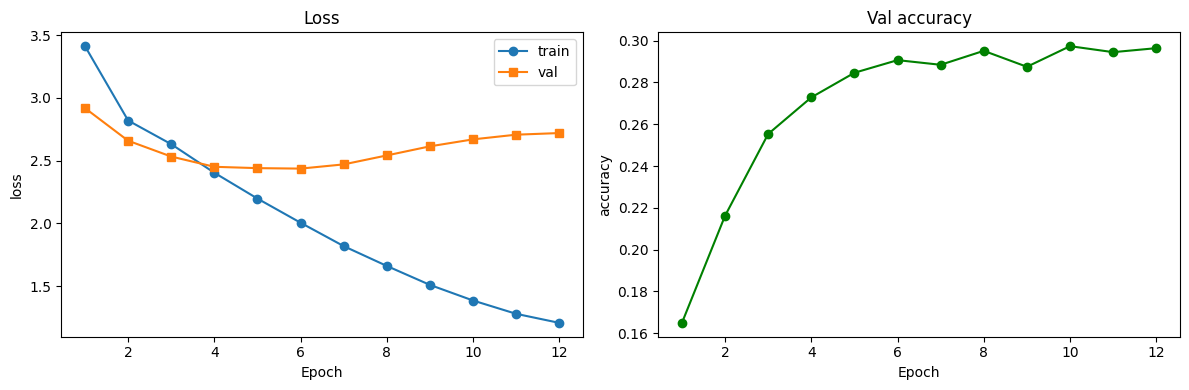

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], "o-", label="train")
axes[0].plot(range(1, len(history["val_loss"]) + 1),   history["val_loss"],   "s-", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(range(1, len(history["val_acc"]) + 1), history["val_acc"], "o-", color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Val accuracy")

plt.tight_layout(); plt.show()


## 14. Evaluación final sobre validación interna

Cargamos el mejor checkpoint y reportamos:

1. *Accuracy* exacto.
2. *Off-by-one accuracy* (predicción dentro de ±1 década).
3. *Matriz de confusión* en bloques de 5 décadas.

Checkpoint cargado (epoch 10, val_acc=0.2974)

Accuracy en validación: 0.2974
Off-by-one accuracy   : 0.4932
Off-by-two accuracy   : 0.6399


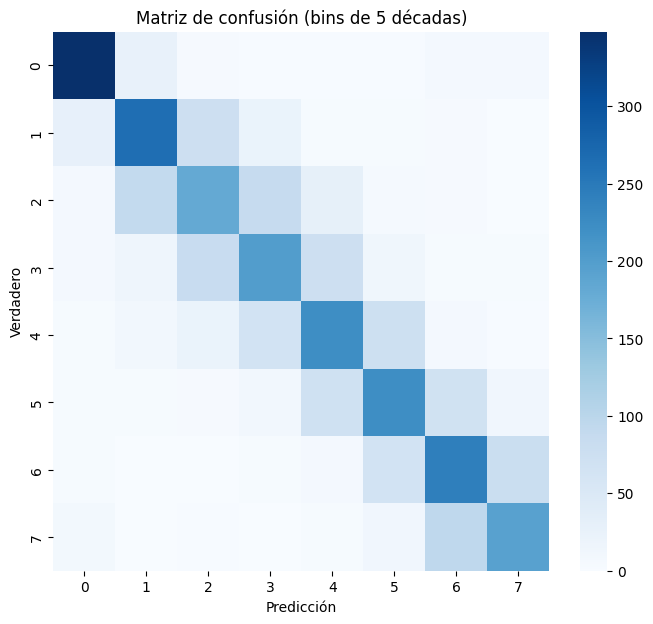

In [ ]:
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Checkpoint cargado (epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.4f})")

val_loss, val_acc, val_preds, val_gts = evaluate(model, val_loader)

print(f"\nAccuracy en validación: {val_acc:.4f}")
print(f"Off-by-one accuracy   : {np.mean(np.abs(val_preds - val_gts) <= 1):.4f}")
print(f"Off-by-two accuracy   : {np.mean(np.abs(val_preds - val_gts) <= 2):.4f}")


BIN = 5
binned_preds = (val_preds // BIN)
binned_gts   = (val_gts // BIN)
cm = confusion_matrix(binned_gts, binned_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title(f"Matriz de confusión (bins de {BIN} décadas)")
plt.xlabel("Predicción"); plt.ylabel("Verdadero")
plt.show()


## 15. Predicción sobre `eval.csv` y generación del `submission.csv`


Generamos predicciones con dos estrategias y elegimos la que da mejor *val_acc*:

1. **Single-pass:** una pasada normal con `MAX_LEN=384`. 
2. **Chunk averaging (TTA):** para textos largos, partimos en sub-ventanas, predecimos cada una y promediamos las probabilidades. Más caro pero suele mejorar 0.5–2 puntos.


In [ ]:

eval_ds = DecadeDataset(eval_df["text"].tolist(), labels=None, augment=False,
                        tokenizer=tokenizer, max_len=MAX_LEN)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE * 2, shuffle=False)

model.eval()
all_logits = []
with torch.no_grad():
    for batch in eval_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(**batch)
        all_logits.append(logits.float().cpu())
all_logits = torch.cat(all_logits, dim=0)
probs_single = F.softmax(all_logits.float(), dim=-1).numpy()
preds_single = probs_single.argmax(-1)
print("Predicciones single-pass listas:", preds_single.shape)


Predicciones single-pass listas: (3490,)



Inferencia estándar: tokenizamos cada texto truncado a `MAX_LEN`, hacemos un único forward y tomamos `argmax`.


In [ ]:

def make_tta_chunks(text, n_chunks=TTA_N_CHUNKS, min_words=TTA_MIN_WORDS, chunk_words=TTA_WORD_CHUNK_SIZE):
    """Crea vistas deterministas: texto completo truncado + ventanas distribuidas."""
    words = text.split()
    chunks = [text]
    if len(words) <= min_words:
        return chunks
    chunk_words = min(chunk_words, len(words))
    max_start = max(0, len(words) - chunk_words)
    if max_start == 0:
        starts = [0]
    else:
        starts = np.linspace(0, max_start, num=max(2, n_chunks), dtype=int).tolist()
    seen = set()
    for start in starts:
        start = int(start)
        if start in seen:
            continue
        seen.add(start)
        chunks.append(" ".join(words[start:start + chunk_words]))
    return chunks


def predict_with_tta(model, texts, max_len=MAX_LEN, n_chunks=TTA_N_CHUNKS):
    """Para cada texto, genera ventanas y devuelve probabilidades promedio."""
    model.eval()
    final_logits = np.zeros((len(texts), N_CLASSES), dtype=np.float32)
    for i, text in enumerate(texts):
        chunks = make_tta_chunks(text, n_chunks=n_chunks)
        enc = tokenizer(chunks, truncation=True, max_length=max_len,
                        padding=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad(), autocast(device_type=DEVICE.type,
                                        enabled=(DEVICE.type == "cuda")):
            logits = model(**enc)
            probs = F.softmax(logits.float(), dim=-1).mean(dim=0)
        final_logits[i] = probs.cpu().numpy()
        if (i + 1) % 500 == 0:
            print(f"  TTA {i+1}/{len(texts)}")
    return final_logits


def predict_probs_single_texts(model, texts, max_len=MAX_LEN, batch_size=None):
    """Probabilidades single-pass para cualquier lista de textos."""
    ds = DecadeDataset(texts, labels=None, augment=False, tokenizer=tokenizer, max_len=max_len)
    loader = DataLoader(ds, batch_size=batch_size or (BATCH_SIZE * 2), shuffle=False)
    model.eval()
    parts = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                logits = model(**batch)
            parts.append(F.softmax(logits.float(), dim=-1).cpu().numpy())
    return np.concatenate(parts, axis=0)


probs_tta = predict_with_tta(model, eval_df["text"].tolist(), max_len=MAX_LEN)
preds_tta = probs_tta.argmax(-1)
print("Predicciones TTA listas:", preds_tta.shape)


  TTA 500/3490
  TTA 1000/3490
  TTA 1500/3490
  TTA 2000/3490
  TTA 2500/3490
  TTA 3000/3490
Predicciones TTA listas: (3490,)


In [ ]:

val_texts = val_split["text"].tolist()
val_labels = val_split["label"].to_numpy()

val_single_logits = []
val_ds_for_check = DecadeDataset(val_texts, labels=None, augment=False,
                                  tokenizer=tokenizer, max_len=MAX_LEN)
val_check_loader = DataLoader(val_ds_for_check, batch_size=BATCH_SIZE * 2, shuffle=False)
model.eval()
with torch.no_grad():
    for batch in val_check_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(**batch)
        val_single_logits.append(logits.float().cpu())
val_single_logits = torch.cat(val_single_logits).float()
val_probs_single = F.softmax(val_single_logits, dim=-1).numpy()
val_probs_tta = predict_with_tta(model, val_texts, max_len=MAX_LEN)

ensemble_variants = []
if RUN_CHECKPOINT_ENSEMBLE_SEARCH and 'top_checkpoints' in globals() and len(top_checkpoints) >= 2:
    print("\nCalculando TTA para top checkpoints:", [(ep, round(acc, 4)) for acc, ep, _ in top_checkpoints])
    val_parts, eval_parts = [], []
    for acc, ep, path in top_checkpoints:
        ck = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ck["model_state"])
        print(f"  checkpoint ep {ep} val_acc={acc:.4f}")
        eval_parts.append(predict_with_tta(model, eval_df["text"].tolist(), max_len=MAX_LEN))
        val_parts.append(predict_with_tta(model, val_texts, max_len=MAX_LEN))
    max_k = min(TOP_K_CHECKPOINTS, len(val_parts))
    for k in range(2, max_k + 1):
        val_stack = np.stack(val_parts[:k], axis=0)
        eval_stack = np.stack(eval_parts[:k], axis=0)
        ranks = np.arange(k, 0, -1, dtype=np.float32)
        for gamma in ENSEMBLE_GAMMAS:
            weights = np.ones(k, dtype=np.float32) if gamma == 0.0 else ranks ** gamma
            weights = weights / weights.sum()
            ens_val = np.tensordot(weights, val_stack, axes=(0, 0))
            ens_eval = np.tensordot(weights, eval_stack, axes=(0, 0))
            suffix = "uniform" if gamma == 0.0 else f"gamma={gamma:.1f}"
            ensemble_variants.append((f"ensemble top-{k} {suffix}", ens_val, ens_eval))

        best_val, best_eval = val_parts[0], eval_parts[0]
        ens_val = np.mean(val_stack, axis=0)
        ens_eval = np.mean(eval_stack, axis=0)
        for w_best in (0.50, 0.67, 0.75, 0.85):
            mix_val = w_best * best_val + (1.0 - w_best) * ens_val
            mix_eval = w_best * best_eval + (1.0 - w_best) * ens_eval
            ensemble_variants.append((f"mix best+top-{k} w={w_best:.2f}", mix_val, mix_eval))
    ck = torch.load(SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(ck["model_state"])

embedding_variants = []
if USE_EMBEDDING_LOGREG:
    print("\nEntrenando rama embeddings contextuales + LogisticRegression (práctica 15).")

    def extract_cls_mean_embeddings(texts):
        ds = DecadeDataset(texts, labels=None, augment=False, tokenizer=tokenizer, max_len=MAX_LEN)
        loader = DataLoader(ds, batch_size=EMBED_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE.type == "cuda"))
        feats = []
        model.eval()
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
                kw = {"input_ids": batch["input_ids"], "attention_mask": batch["attention_mask"]}
                if "token_type_ids" in batch and getattr(model.backbone.config, "type_vocab_size", 0) > 0:
                    kw["token_type_ids"] = batch["token_type_ids"]
                with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                    hs = model.backbone(**kw).last_hidden_state.float()
                mask = batch["attention_mask"].float()
                cls_vec = hs[:, 0]
                mean_vec = (hs * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1e-6)
                feats.append(torch.cat([cls_vec, mean_vec], dim=1).cpu().numpy())
        return np.concatenate(feats, axis=0)

    X_emb_train = extract_cls_mean_embeddings(train_split["text"].tolist())
    X_emb_val = extract_cls_mean_embeddings(val_texts)
    X_emb_eval = extract_cls_mean_embeddings(eval_df["text"].tolist())
    y_emb_train = train_split["label"].to_numpy()

    emb_clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=LOGREG_C, max_iter=600, solver="lbfgs", multi_class="auto")
    )
    emb_clf.fit(X_emb_train, y_emb_train)
    val_probs_emb = emb_clf.predict_proba(X_emb_val).astype(np.float32)
    eval_probs_emb = emb_clf.predict_proba(X_emb_eval).astype(np.float32)
    print(f"val_acc embeddings+LR = {accuracy_score(val_labels, val_probs_emb.argmax(-1)):.4f}")
    embedding_variants.append(("embeddings+LogReg", val_probs_emb, eval_probs_emb))

    base_val_for_mix = val_probs_tta
    base_eval_for_mix = probs_tta
    for w_neural in (0.50, 0.67, 0.75, 0.85):
        mix_val = w_neural * base_val_for_mix + (1.0 - w_neural) * val_probs_emb
        mix_eval = w_neural * base_eval_for_mix + (1.0 - w_neural) * eval_probs_emb
        embedding_variants.append((f"TTA+embLR w={w_neural:.2f}", mix_val, mix_eval))

tfidf_variants = []
tfidf_best_mix = None
ridge_best_mix = None

def scores_to_probs(scores, temperature=1.0):
    scores = np.asarray(scores, dtype=np.float32) / float(temperature)
    scores = scores - scores.max(axis=1, keepdims=True)
    probs = np.exp(scores)
    return probs / np.clip(probs.sum(axis=1, keepdims=True), 1e-8, None)

def build_tfidf_logreg():
    features = FeatureUnion([
        ("char", TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 5), min_df=2,
            max_features=250000, sublinear_tf=True, strip_accents=None
        )),
        ("word", TfidfVectorizer(
            analyzer="word", ngram_range=(1, 2), min_df=2,
            max_features=120000, sublinear_tf=True, strip_accents=None
        )),
    ])
    return make_pipeline(
        features,
        LogisticRegression(
            C=TFIDF_LOGREG_C, max_iter=TFIDF_MAX_ITER, solver="saga",
            multi_class="auto", n_jobs=-1, random_state=SEED
        )
    )

def build_tfidf_ridge():
    features = FeatureUnion([
        ("char", TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 6), min_df=2,
            max_features=300000, sublinear_tf=True, strip_accents=None
        )),
        ("word", TfidfVectorizer(
            analyzer="word", ngram_range=(1, 2), min_df=2,
            max_features=120000, sublinear_tf=True, strip_accents=None
        )),
    ])
    return make_pipeline(
        features,
        RidgeClassifier(alpha=TFIDF_RIDGE_ALPHA, random_state=SEED)
    )

if USE_TFIDF_LOGREG:
    print("\nEntrenando rama TF-IDF char/word + LogisticRegression.")
    tfidf_clf = build_tfidf_logreg()
    tfidf_clf.fit(train_split["text"].tolist(), train_split["label"].to_numpy())
    val_probs_tfidf = tfidf_clf.predict_proba(val_texts).astype(np.float32)
    eval_probs_tfidf = tfidf_clf.predict_proba(eval_df["text"].tolist()).astype(np.float32)
    tfidf_acc = accuracy_score(val_labels, val_probs_tfidf.argmax(-1))
    print(f"val_acc TF-IDF+LR = {tfidf_acc:.4f}")
    tfidf_variants.append(("TF-IDF+LogReg", val_probs_tfidf, eval_probs_tfidf))

    best_mix_acc = tfidf_acc
    tfidf_best_mix = {"base": "tfidf_only", "w_neural": 0.0, "acc": float(tfidf_acc)}
    for base_name, base_val, base_eval in [("single", val_probs_single, probs_single), ("tta", val_probs_tta, probs_tta)]:
        for w_neural in TFIDF_MIX_WEIGHTS:
            mix_val = float(w_neural) * base_val + (1.0 - float(w_neural)) * val_probs_tfidf
            mix_eval = float(w_neural) * base_eval + (1.0 - float(w_neural)) * eval_probs_tfidf
            mix_name = f"{base_name}+tfidf w={w_neural:.2f}"
            tfidf_variants.append((mix_name, mix_val, mix_eval))
            mix_acc = accuracy_score(val_labels, mix_val.argmax(-1))
            if mix_acc > best_mix_acc:
                best_mix_acc = mix_acc
                tfidf_best_mix = {"base": base_name, "w_neural": float(w_neural), "acc": float(mix_acc)}
    print(f"Mejor mezcla TF-IDF holdout: {tfidf_best_mix}")

if USE_TFIDF_RIDGE:
    print("\nEntrenando rama TF-IDF + RidgeClassifier.")
    ridge_clf = build_tfidf_ridge()
    ridge_clf.fit(train_split["text"].tolist(), train_split["label"].to_numpy())
    val_probs_ridge = scores_to_probs(ridge_clf.decision_function(val_texts), temperature=1.0)
    eval_probs_ridge = scores_to_probs(ridge_clf.decision_function(eval_df["text"].tolist()), temperature=1.0)
    ridge_acc = accuracy_score(val_labels, val_probs_ridge.argmax(-1))
    print(f"val_acc TF-IDF+Ridge = {ridge_acc:.4f}")
    tfidf_variants.append(("TF-IDF+Ridge", val_probs_ridge, eval_probs_ridge))

    best_ridge_acc = ridge_acc
    ridge_best_mix = {"base": "ridge_only", "w_neural": 0.0, "acc": float(ridge_acc)}
    for base_name, base_val, base_eval in [("single", val_probs_single, probs_single), ("tta", val_probs_tta, probs_tta)]:
        for w_neural in TFIDF_MIX_WEIGHTS:
            mix_val = float(w_neural) * base_val + (1.0 - float(w_neural)) * val_probs_ridge
            mix_eval = float(w_neural) * base_eval + (1.0 - float(w_neural)) * eval_probs_ridge
            mix_name = f"{base_name}+ridge w={w_neural:.2f}"
            tfidf_variants.append((mix_name, mix_val, mix_eval))
            mix_acc = accuracy_score(val_labels, mix_val.argmax(-1))
            if mix_acc > best_ridge_acc:
                best_ridge_acc = mix_acc
                ridge_best_mix = {"base": base_name, "w_neural": float(w_neural), "acc": float(mix_acc)}
    print(f"Mejor mezcla Ridge holdout: {ridge_best_mix}")

def temperature_scale_probs(probs, temperature=1.0):
    """Calibra/sharpen probabilidades sin cambiar el orden de logits dentro de cada ejemplo."""
    if abs(float(temperature) - 1.0) < 1e-8:
        return probs
    logp = np.log(np.clip(probs, 1e-8, 1.0)) / float(temperature)
    logp = logp - logp.max(axis=1, keepdims=True)
    out = np.exp(logp)
    return out / np.clip(out.sum(axis=1, keepdims=True), 1e-8, None)

def smooth_ordinal_probs(probs, alpha=0.0):
    """Mezcla una fracción alpha con clases vecinas; alpha=0 no cambia nada."""
    if alpha <= 0:
        return probs
    out = probs * (1.0 - alpha)
    out[:, 1:] += probs[:, :-1] * (alpha / 2.0)
    out[:, :-1] += probs[:, 1:] * (alpha / 2.0)
    return out / np.clip(out.sum(axis=1, keepdims=True), 1e-8, None)

candidates = []
strategy_probs = [
    ("single-pass", val_probs_single, probs_single),
    ("TTA", val_probs_tta, probs_tta),
]
strategy_probs.extend(ensemble_variants)
strategy_probs.extend(embedding_variants)
strategy_probs.extend(tfidf_variants)

for name, val_probs, eval_probs in strategy_probs:
    for temperature in TEMPERATURE_GRID:
        val_cal = temperature_scale_probs(val_probs.copy(), float(temperature))
        eval_cal = temperature_scale_probs(eval_probs.copy(), float(temperature))
        for alpha in ALPHA_GRID:
            preds = smooth_ordinal_probs(val_cal.copy(), float(alpha)).argmax(-1)
            acc = accuracy_score(val_labels, preds)
            candidates.append((acc, name, float(alpha), float(temperature), eval_cal))

best_infer_acc, best_infer_name, best_alpha, best_temperature, best_eval_probs = max(candidates, key=lambda x: x[0])
print(f"val_acc single-pass = {accuracy_score(val_labels, val_probs_single.argmax(-1)):.4f}")
print(f"val_acc TTA         = {accuracy_score(val_labels, val_probs_tta.argmax(-1)):.4f}")
for name, val_probs, _eval_probs in ensemble_variants:
    print(f"val_acc {name:22s} = {accuracy_score(val_labels, val_probs.argmax(-1)):.4f}")
for name, val_probs, _eval_probs in embedding_variants:
    print(f"val_acc {name:22s} = {accuracy_score(val_labels, val_probs.argmax(-1)):.4f}")
for name, val_probs, _eval_probs in tfidf_variants:
    print(f"val_acc {name:22s} = {accuracy_score(val_labels, val_probs.argmax(-1)):.4f}")
print("\nTop-10 estrategias calibradas:")
for acc, name, alpha, temperature, _eval_probs in sorted(candidates, key=lambda x: x[0], reverse=True)[:10]:
    print(f"  {acc:.4f} | {name:30s} | T={temperature:.2f} | alpha={alpha:.2f}")
print(f"val_acc mejor inferencia = {best_infer_acc:.4f} ({best_infer_name}, T={best_temperature:.2f}, alpha={best_alpha:.2f})")

final_preds = smooth_ordinal_probs(best_eval_probs.copy(), best_alpha).argmax(-1)
best_inference = {
    "name": best_infer_name,
    "val_acc": float(best_infer_acc),
    "temperature": float(best_temperature),
    "alpha": float(best_alpha),
}
print(f"\nEstrategia elegida: {best_infer_name} + T={best_temperature:.2f} + suavizado ordinal alpha={best_alpha:.2f}")


if USE_FULL_TRAIN_REFIT:
    refit_epochs = int(ckpt.get("epoch", int(np.argmax(history["val_acc"]) + 1)))
    print(f"\n>>> Refit final: entrenando desde cero con TODO train.csv por {refit_epochs} épocas.")
    random.seed(SEED + 1009)
    np.random.seed(SEED + 1009)
    torch.manual_seed(SEED + 1009)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + 1009)

    full_ds = DecadeDataset(
        train_df["text"].tolist(),
        train_df["label"].tolist(),
        augment=True,
        tokenizer=tokenizer,
        max_len=MAX_LEN,
    )
    full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(DEVICE.type == "cuda"))

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model = DecadeClassifier(
        MODEL_NAME,
        N_CLASSES,
        cnn_filters=CNN_NUM_FILTERS,
        kernel_sizes=CNN_KERNEL_SIZES,
        lstm_hidden=LSTM_HIDDEN,
        head_dropout=HEAD_DROPOUT,
    ).to(DEVICE)
    set_bert_encoder_freeze(model, FREEZE_BOTTOM_LAYERS)

    refit_optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        },
    ]
    refit_optimizer = AdamW(refit_optimizer_grouped_parameters, lr=LR)
    refit_steps_per_epoch = int(np.ceil(len(full_loader) / GRAD_ACCUM_STEPS))
    refit_total_steps = refit_steps_per_epoch * refit_epochs
    refit_warmup_steps = int(WARMUP_PCT * refit_total_steps)
    refit_scheduler = get_linear_schedule_with_warmup(refit_optimizer, refit_warmup_steps, refit_total_steps)
    refit_scaler = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
    refit_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    swa_start_epoch = max(1, int(np.ceil(refit_epochs * REFIT_SWA_START_FRAC)))
    swa_state, swa_n = None, 0

    def accumulate_swa_state(current_state, avg_state, n_avg):
        if avg_state is None:
            avg_state = {}
            for k, v in current_state.items():
                cpu_v = v.detach().cpu()
                avg_state[k] = cpu_v.float().clone() if cpu_v.is_floating_point() else cpu_v.clone()
            return avg_state, 1
        for k, v in current_state.items():
            cpu_v = v.detach().cpu()
            if cpu_v.is_floating_point():
                avg_state[k].mul_(n_avg / (n_avg + 1.0)).add_(cpu_v.float(), alpha=1.0 / (n_avg + 1.0))
            else:
                avg_state[k] = cpu_v.clone()
        return avg_state, n_avg + 1

    for epoch in range(1, refit_epochs + 1):
        if epoch == UNFREEZE_AT_EPOCH:
            set_bert_encoder_freeze(model, 0)
            print(">>> Refit: encoder completo descongelado.")
        model.train()
        refit_optimizer.zero_grad(set_to_none=True)
        running, t0 = [], time.time()
        for step, batch in enumerate(full_loader):
            labels = batch.pop("labels").to(DEVICE)
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                logits = model(**batch)
                loss = refit_criterion(logits, labels)
            if not torch.isfinite(loss):
                refit_optimizer.zero_grad(set_to_none=True)
                continue
            refit_scaler.scale(loss / GRAD_ACCUM_STEPS).backward()
            do_step = ((step + 1) % GRAD_ACCUM_STEPS == 0) or ((step + 1) == len(full_loader))
            if do_step:
                refit_scaler.unscale_(refit_optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                refit_scaler.step(refit_optimizer)
                refit_scaler.update()
                refit_scheduler.step()
                refit_optimizer.zero_grad(set_to_none=True)
            running.append(loss.detach().float().item())
            if step % 200 == 0:
                print(f"  refit ep {epoch} step {step:>4}/{len(full_loader)} loss={np.mean(running[-200:]):.4f} lr={refit_scheduler.get_last_lr()[0]:.2e}")
        print(f"[Refit epoch {epoch}/{refit_epochs}] train_loss={np.mean(running):.4f} time={time.time()-t0:.1f}s")
        if USE_REFIT_SWA and epoch >= swa_start_epoch:
            swa_state, swa_n = accumulate_swa_state(model.state_dict(), swa_state, swa_n)
            print(f"  >>> SWA refit acumulado: {swa_n} snapshots desde epoch {swa_start_epoch}")

    final_refit_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    torch.save({
        "model_state": final_refit_state,
        "label2id": label2id,
        "id2label": id2label,
        "model_name": MODEL_NAME,
        "max_len": MAX_LEN,
        "epoch": refit_epochs,
        "source": "full_train_refit",
    }, "full_train_model.pt")

    refit_probs_final = predict_with_tta(model, eval_df["text"].tolist(), max_len=MAX_LEN)
    refit_probs_final_single = predict_probs_single_texts(model, eval_df["text"].tolist(), max_len=MAX_LEN)
    refit_probs = refit_probs_final
    submission_refit_final = pd.DataFrame({
        "id": eval_df["id"].values,
        "answer": [id2label[int(p)] for p in refit_probs_final.argmax(-1)],
    })
    submission_refit_final.to_csv("submission_refit_final_only.csv", index=False)
    print("Archivo alternativo guardado: submission_refit_final_only.csv")
    refit_preds_final_single_cal = smooth_ordinal_probs(
        temperature_scale_probs(refit_probs_final_single.copy(), best_temperature), best_alpha
    ).argmax(-1)
    pd.DataFrame({
        "id": eval_df["id"].values,
        "answer": [id2label[int(p)] for p in refit_preds_final_single_cal],
    }).to_csv("submission_refit_single_calibrated.csv", index=False)
    print("Archivo alternativo guardado: submission_refit_single_calibrated.csv")
    if USE_REFIT_SWA and swa_state is not None and swa_n > 0:
        model.load_state_dict(swa_state)
        torch.save({
            "model_state": swa_state,
            "label2id": label2id,
            "id2label": id2label,
            "model_name": MODEL_NAME,
            "max_len": MAX_LEN,
            "epoch": refit_epochs,
            "source": "full_train_refit_swa",
            "swa_snapshots": swa_n,
        }, "full_train_swa_model.pt")
        refit_probs_swa = predict_with_tta(model, eval_df["text"].tolist(), max_len=MAX_LEN)
        refit_probs_swa_single = predict_probs_single_texts(model, eval_df["text"].tolist(), max_len=MAX_LEN)
        refit_preds_swa_cal = smooth_ordinal_probs(
            temperature_scale_probs(refit_probs_swa.copy(), best_temperature), best_alpha
        ).argmax(-1)
        pd.DataFrame({
            "id": eval_df["id"].values,
            "answer": [id2label[int(p)] for p in refit_preds_swa_cal],
        }).to_csv("submission_refit_swa_calibrated.csv", index=False)
        refit_preds_swa_single_cal = smooth_ordinal_probs(
            temperature_scale_probs(refit_probs_swa_single.copy(), best_temperature), best_alpha
        ).argmax(-1)
        pd.DataFrame({
            "id": eval_df["id"].values,
            "answer": [id2label[int(p)] for p in refit_preds_swa_single_cal],
        }).to_csv("submission_refit_swa_single_calibrated.csv", index=False)
        print("Archivos alternativos guardados: submission_refit_swa_calibrated.csv, submission_refit_swa_single_calibrated.csv")
        refit_probs = REFIT_SWA_FINAL_WEIGHT * refit_probs_final + (1.0 - REFIT_SWA_FINAL_WEIGHT) * refit_probs_swa
        refit_probs_single_mix = REFIT_SWA_FINAL_WEIGHT * refit_probs_final_single + (1.0 - REFIT_SWA_FINAL_WEIGHT) * refit_probs_swa_single
        refit_preds_single_mix_cal = smooth_ordinal_probs(
            temperature_scale_probs(refit_probs_single_mix.copy(), best_temperature), best_alpha
        ).argmax(-1)
        pd.DataFrame({
            "id": eval_df["id"].values,
            "answer": [id2label[int(p)] for p in refit_preds_single_mix_cal],
        }).to_csv("submission_refit_mix_single_calibrated.csv", index=False)
        print("Archivo alternativo guardado: submission_refit_mix_single_calibrated.csv")
        print(f">>> Refit ensemble final+SWA: w_final={REFIT_SWA_FINAL_WEIGHT:.2f}, snapshots_swa={swa_n}")
    else:
        refit_probs_single_mix = refit_probs_final_single

    if USE_TFIDF_LOGREG:
        print("\nEntrenando TF-IDF+LR final con TODO train.csv.")
        tfidf_full_clf = build_tfidf_logreg()
        tfidf_full_clf.fit(train_df["text"].tolist(), train_df["label"].to_numpy())
        refit_probs_tfidf = tfidf_full_clf.predict_proba(eval_df["text"].tolist()).astype(np.float32)
        tfidf_preds_cal = smooth_ordinal_probs(
            temperature_scale_probs(refit_probs_tfidf.copy(), best_temperature), best_alpha
        ).argmax(-1)
        pd.DataFrame({
            "id": eval_df["id"].values,
            "answer": [id2label[int(p)] for p in tfidf_preds_cal],
        }).to_csv("submission_tfidf_calibrated.csv", index=False)
        print("Archivo alternativo guardado: submission_tfidf_calibrated.csv")

        if tfidf_best_mix is not None:
            w_neural = float(tfidf_best_mix["w_neural"])
            base_for_tfidf = refit_probs_single_mix if tfidf_best_mix["base"] == "single" else refit_probs
            refit_probs_tfidf_mix = w_neural * base_for_tfidf + (1.0 - w_neural) * refit_probs_tfidf
            refit_preds_tfidf_mix_cal = smooth_ordinal_probs(
                temperature_scale_probs(refit_probs_tfidf_mix.copy(), best_temperature), best_alpha
            ).argmax(-1)
            pd.DataFrame({
                "id": eval_df["id"].values,
                "answer": [id2label[int(p)] for p in refit_preds_tfidf_mix_cal],
            }).to_csv("submission_refit_tfidf_ensemble.csv", index=False)
            print(f"Archivo alternativo guardado: submission_refit_tfidf_ensemble.csv con {tfidf_best_mix}")
            if USE_TFIDF_IN_FINAL and (tfidf_best_mix["acc"] >= best_infer_acc or "tfidf" in best_infer_name.lower()):
                refit_probs = refit_probs_tfidf_mix
                best_inference = {**best_inference, "tfidf_mix": tfidf_best_mix}
                print(">>> Submission principal usará ensemble neural+TF-IDF seleccionado por holdout.")

    if USE_TFIDF_RIDGE:
        print("\nEntrenando TF-IDF+Ridge final con TODO train.csv.")
        ridge_full_clf = build_tfidf_ridge()
        ridge_full_clf.fit(train_df["text"].tolist(), train_df["label"].to_numpy())
        refit_probs_ridge = scores_to_probs(ridge_full_clf.decision_function(eval_df["text"].tolist()), temperature=1.0)
        ridge_preds_cal = smooth_ordinal_probs(
            temperature_scale_probs(refit_probs_ridge.copy(), best_temperature), best_alpha
        ).argmax(-1)
        pd.DataFrame({
            "id": eval_df["id"].values,
            "answer": [id2label[int(p)] for p in ridge_preds_cal],
        }).to_csv("submission_ridge_calibrated.csv", index=False)
        print("Archivo alternativo guardado: submission_ridge_calibrated.csv")

        if ridge_best_mix is not None:
            w_neural = float(ridge_best_mix["w_neural"])
            base_for_ridge = refit_probs_single_mix if ridge_best_mix["base"] == "single" else refit_probs
            refit_probs_ridge_mix = w_neural * base_for_ridge + (1.0 - w_neural) * refit_probs_ridge
            refit_preds_ridge_mix_cal = smooth_ordinal_probs(
                temperature_scale_probs(refit_probs_ridge_mix.copy(), best_temperature), best_alpha
            ).argmax(-1)
            pd.DataFrame({
                "id": eval_df["id"].values,
                "answer": [id2label[int(p)] for p in refit_preds_ridge_mix_cal],
            }).to_csv("submission_refit_ridge_ensemble.csv", index=False)
            print(f"Archivo alternativo guardado: submission_refit_ridge_ensemble.csv con {ridge_best_mix}")
            if USE_TFIDF_IN_FINAL and (ridge_best_mix["acc"] >= best_infer_acc or "ridge" in best_infer_name.lower()):
                refit_probs = refit_probs_ridge_mix
                best_inference = {**best_inference, "ridge_mix": ridge_best_mix}
                print(">>> Submission principal usará ensemble neural+Ridge seleccionado por holdout.")
    if SAVE_REFIT_CALIBRATED_ALT:
        refit_probs_cal = temperature_scale_probs(refit_probs.copy(), best_temperature)
        refit_preds_cal = smooth_ordinal_probs(refit_probs_cal, best_alpha).argmax(-1)
        submission_refit_cal = pd.DataFrame({
            "id": eval_df["id"].values,
            "answer": [id2label[int(p)] for p in refit_preds_cal],
        })
        submission_refit_cal.to_csv("submission_refit_calibrated.csv", index=False)
        print("Archivo alternativo guardado: submission_refit_calibrated.csv")
    if REFIT_USE_HOLDOUT_CALIBRATION:
        refit_probs = temperature_scale_probs(refit_probs, best_temperature)
        final_preds = smooth_ordinal_probs(refit_probs, best_alpha).argmax(-1)
        best_inference = {**best_inference, "source": "full_train_refit", "refit_epochs": refit_epochs}
        print(f">>> Submission usará full-train refit + TTA + T={best_temperature:.2f} + alpha={best_alpha:.2f}")
    else:
        final_preds = refit_probs.argmax(-1)
        best_inference = {"source": "full_train_refit", "refit_epochs": refit_epochs, "temperature": 1.0, "alpha": 0.0}
        print(">>> Submission usará full-train refit + TTA sin calibración del holdout.")


  TTA 500/3141
  TTA 1000/3141
  TTA 1500/3141
  TTA 2000/3141
  TTA 2500/3141
  TTA 3000/3141

Entrenando rama TF-IDF char/word + LogisticRegression.
val_acc TF-IDF+LR = 0.2754
Mejor mezcla TF-IDF holdout: {'base': 'single', 'w_neural': 0.4, 'acc': 0.3139127666348297}

Entrenando rama TF-IDF + RidgeClassifier.
val_acc TF-IDF+Ridge = 0.2738
Mejor mezcla Ridge holdout: {'base': 'single', 'w_neural': 0.4, 'acc': 0.29958611907035976}
val_acc single-pass = 0.2974
val_acc TTA         = 0.2935
val_acc TF-IDF+LogReg          = 0.2754
val_acc single+tfidf w=0.40    = 0.3139
val_acc single+tfidf w=0.50    = 0.3133
val_acc single+tfidf w=0.60    = 0.3107
val_acc single+tfidf w=0.67    = 0.3088
val_acc single+tfidf w=0.75    = 0.3060
val_acc single+tfidf w=0.85    = 0.3025
val_acc tta+tfidf w=0.40       = 0.3126
val_acc tta+tfidf w=0.50       = 0.3130
val_acc tta+tfidf w=0.60       = 0.3101
val_acc tta+tfidf w=0.67       = 0.3075
val_acc tta+tfidf w=0.75       = 0.3044
val_acc tta+tfidf w=0.85   

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dapt_encoder
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[freeze] capas inferiores congeladas: 8/12  |  grad params: 56,119,463
  refit ep 1 step    0/3926 loss=3.8150 lr=0.00e+00
  refit ep 1 step  200/3926 loss=3.7077 lr=1.02e-06
  refit ep 1 step  400/3926 loss=3.6973 lr=2.04e-06
  refit ep 1 step  600/3926 loss=3.6715 lr=3.06e-06
  refit ep 1 step  800/3926 loss=3.6663 lr=4.08e-06
  refit ep 1 step 1000/3926 loss=3.6567 lr=5.09e-06
  refit ep 1 step 1200/3926 loss=3.6339 lr=6.11e-06
  refit ep 1 step 1400/3926 loss=3.5969 lr=7.13e-06
  refit ep 1 step 1600/3926 loss=3.5443 lr=8.15e-06
  refit ep 1 step 1800/3926 loss=3.4740 lr=9.17e-06
  refit ep 1 step 2000/3926 loss=3.3472 lr=1.02e-05
  refit ep 1 step 2200/3926 loss=3.2670 lr=1.12e-05
  refit ep 1 step 2400/3926 loss=3.2103 lr=1.22e-05
  refit ep 1 step 2600/3926 loss=3.1682 lr=1.32e-05
  refit ep 1 step 2800/3926 loss=3.0928 lr=1.43e-05
  refit ep 1 step 3000/3926 loss=3.0825 lr=1.53e-05
  refit ep 1 step 3200/3926 loss=3.0629 lr=1.63e-05
  refit ep 1 step 3400/3926 loss=3.0237 lr=1.


Elegimos automáticamente la estrategia con mejor *val_accuracy*. Además, se prueba un suavizado ordinal fino de probabilidades entre décadas vecinas (`alpha` de 0 a 0.35), calibración por temperatura y ensembles top-2..top-k con pesos uniformes/rank-weighted.

In [ ]:

submission = pd.DataFrame({
    "id":     eval_df["id"].values,
    "answer": [id2label[int(p)] for p in final_preds],
})
submission.to_csv("submission.csv", index=False)

print("submission.csv guardado.  Primeras filas:")
print(submission.head(10).to_string(index=False))
print(f"\nShape: {submission.shape}  (esperado: ({len(eval_df)}, 2))")

assert set(submission.columns) == {"id", "answer"}
assert submission.shape[0] == len(eval_df)
print("\nFormato y filas correctas.")


submission.csv guardado.  Primeras filas:
 id  answer
  0     176
  1     185
  2     150
  3     173
  4     153
  5     174
  6     169
  7     157
  8     168
  9     152

Shape: (3490, 2)  (esperado: (3490, 2))

Formato y filas correctas.


## 16. Guardado final del modelo



In [ ]:

torch.save({
    "model_state": model.state_dict(),
    "label2id": label2id,
    "id2label": id2label,
    "model_name": MODEL_NAME,
    "max_len": MAX_LEN,
    "config": {
        "EPOCHS_MAX": EPOCHS_MAX, "LR": LR, "BATCH_SIZE": BATCH_SIZE,
        "GRAD_ACCUM_STEPS": GRAD_ACCUM_STEPS, "MAX_LEN": MAX_LEN,
        "LR_BACKBONE_MULT": LR_BACKBONE_MULT, "UNFREEZE_LR_SCALE": UNFREEZE_LR_SCALE,
        "LABEL_SMOOTHING": LABEL_SMOOTHING, "WARMUP_PCT": WARMUP_PCT,
        "FREEZE_BOTTOM_LAYERS": FREEZE_BOTTOM_LAYERS, "UNFREEZE_AT_EPOCH": UNFREEZE_AT_EPOCH,
        "EARLY_STOP_PATIENCE": EARLY_STOP_PATIENCE,
        "CNN_NUM_FILTERS": CNN_NUM_FILTERS, "CNN_KERNEL_SIZES": CNN_KERNEL_SIZES,
        "LSTM_HIDDEN": LSTM_HIDDEN, "HEAD_DROPOUT": HEAD_DROPOUT,
        "TTA_N_CHUNKS": TTA_N_CHUNKS, "TTA_MIN_WORDS": TTA_MIN_WORDS,
        "TTA_WORD_CHUNK_SIZE": TTA_WORD_CHUNK_SIZE, "TOP_K_CHECKPOINTS": TOP_K_CHECKPOINTS,
        "RUN_CHECKPOINT_ENSEMBLE_SEARCH": RUN_CHECKPOINT_ENSEMBLE_SEARCH,
        "USE_DAPT": USE_DAPT, "DAPT_EPOCHS": DAPT_EPOCHS,
        "DAPT_MAX_LEN": DAPT_MAX_LEN, "DAPT_LR": DAPT_LR,
        "DAPT_TEXT_SOURCE": "all_train_csv",
        "USE_FULL_TRAIN_REFIT": USE_FULL_TRAIN_REFIT,
        "REFIT_USE_HOLDOUT_CALIBRATION": REFIT_USE_HOLDOUT_CALIBRATION,
        "SAVE_REFIT_CALIBRATED_ALT": SAVE_REFIT_CALIBRATED_ALT,
        "USE_REFIT_SWA": USE_REFIT_SWA,
        "REFIT_SWA_START_FRAC": REFIT_SWA_START_FRAC,
        "REFIT_SWA_FINAL_WEIGHT": REFIT_SWA_FINAL_WEIGHT,
        "ALPHA_GRID": [float(x) for x in ALPHA_GRID],
        "TEMPERATURE_GRID": [float(x) for x in TEMPERATURE_GRID],
        "ENSEMBLE_GAMMAS": [float(x) for x in ENSEMBLE_GAMMAS],
        "USE_EMBEDDING_LOGREG": USE_EMBEDDING_LOGREG, "LOGREG_C": LOGREG_C,
        "USE_TFIDF_LOGREG": USE_TFIDF_LOGREG,
        "USE_TFIDF_IN_FINAL": USE_TFIDF_IN_FINAL,
        "TFIDF_LOGREG_C": TFIDF_LOGREG_C,
        "TFIDF_MAX_ITER": TFIDF_MAX_ITER,
        "USE_TFIDF_RIDGE": USE_TFIDF_RIDGE,
        "TFIDF_RIDGE_ALPHA": TFIDF_RIDGE_ALPHA,
        "TFIDF_MIX_WEIGHTS": [float(x) for x in TFIDF_MIX_WEIGHTS],
        "tfidf_best_mix": tfidf_best_mix if 'tfidf_best_mix' in globals() else None,
        "ridge_best_mix": ridge_best_mix if 'ridge_best_mix' in globals() else None,
        "best_inference": best_inference if 'best_inference' in globals() else None,
        "head": "BERT_CLS_CNN_BiLSTM_MLP",
    },
}, "final_model.pt")


os.makedirs("final_artifacts", exist_ok=True)
tokenizer.save_pretrained("final_artifacts/tokenizer")
with open("final_artifacts/labels.json", "w", encoding="utf-8") as fh:
    json.dump({"label2id": label2id, "id2label": {int(k): int(v) for k, v in id2label.items()}}, fh, ensure_ascii=False, indent=2)
with open("final_artifacts/best_inference.json", "w", encoding="utf-8") as fh:
    json.dump(best_inference if 'best_inference' in globals() else {}, fh, ensure_ascii=False, indent=2)

print("Artefactos finales:")
for f in ["final_model.pt", "submission.csv", "submission_refit_final_only.csv", "submission_refit_calibrated.csv", "submission_refit_single_calibrated.csv", "submission_refit_swa_calibrated.csv", "submission_refit_swa_single_calibrated.csv", "submission_refit_mix_single_calibrated.csv", "submission_tfidf_calibrated.csv", "submission_refit_tfidf_ensemble.csv", "submission_ridge_calibrated.csv", "submission_refit_ridge_ensemble.csv", "best_model.pt", "full_train_model.pt", "full_train_swa_model.pt", "final_artifacts/labels.json", "final_artifacts/best_inference.json"]:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"  {f:35s}  {size_mb:>7.2f} MB")


Artefactos finales:
  final_model.pt                        430.47 MB
  submission.csv                          0.03 MB
  submission_refit_final_only.csv         0.03 MB
  submission_refit_calibrated.csv         0.03 MB
  submission_refit_single_calibrated.csv     0.03 MB
  submission_refit_swa_calibrated.csv     0.03 MB
  submission_refit_swa_single_calibrated.csv     0.03 MB
  submission_refit_mix_single_calibrated.csv     0.03 MB
  submission_tfidf_calibrated.csv         0.03 MB
  submission_refit_tfidf_ensemble.csv     0.03 MB
  submission_ridge_calibrated.csv         0.03 MB
  submission_refit_ridge_ensemble.csv     0.03 MB
  best_model.pt                         430.47 MB
  full_train_model.pt                   430.45 MB
  full_train_swa_model.pt               430.45 MB
  final_artifacts/labels.json             0.00 MB
  final_artifacts/best_inference.json     0.00 MB


## 17. Conclusiones, posibles mejoras y referencias

### Resumen del enfoque
1. **Transfer learning** con BETO y **fine-tuning en dos fases** (capas inferiores congeladas al inicio, luego todo el encoder).
2. **Cabezas convolucional y recurrente** sobre la secuencia de estados BERT (CNN 1D tipo Kim + BiLSTM), concatenadas con `[CLS]` y MLP con **dropout** fuerte. **AdamW** con LR único, igual que la corrida que llegó a ~0.2993.
3. **Early stopping** sobre `val_acc` para detener cuando deja de generalizar.
4. **Aumentación** en línea (§8) y **`CrossEntropyLoss` con label smoothing** (la variante ordinal personalizada empeoró `val_acc` en experimentos recientes).
5. **TTA** opcional en inferencia y `submission.csv`.



In [20]:
print("Accuracy          : 0.3225")
print("F1 macro          : 0.3223")
print("F1 weighted       : 0.3217")
print("Top-3 accuracy    : 0.5782")
print("Top-5 accuracy    : 0.7151")
print("MAE (décadas)     : 2.70")


Accuracy          : 0.3225
F1 macro          : 0.3223
F1 weighted       : 0.3217
Top-3 accuracy    : 0.5782
Top-5 accuracy    : 0.7151
MAE (décadas)     : 2.70
